In [57]:
# import libraires
import pandas as pd 

In [58]:
# read csv file using read_csv 
df = pd.read_csv("cleaning_challenge.csv")

### استكشاف البيانات \ Data Explor

In [89]:
# Display first 5 rows 
#روئية الصفوف ال 10 الاولى 
df.head(15)

,Invoice_ID,City,Course_Type,Price,Discount,Final_Total,Enrollment_Date,Rating,Course_Name,Level
0,INV-10001,Mecca,Recorded Subscription,532,266,266,3/17/2023,4.1,Laravel & PHP,Advanced
1,INV-10002,Jeddah,Recorded Subscription,289,0,289,"2023, March 15",4.5,Laravel & PHP,Beginner
2,INV-10003,Dammam,Recorded Subscription,474,94,380,"2023, March 15",4.4,UI/UX Design,Intermediate
3,INV-10004,Khobar,Recorded Subscription,265,0,265,"2023, March 15",4.7,UI/UX Design,Beginner
4,INV-10005,Mecca,Recorded Subscription,228,45,183,22-03-2023,4.6,React & Next.js,Beginner
5,INV-10006,Riyadh,Live Bootcamp,1542,0,1542,1/1/1900,4.5,Flutter Development,Beginner
6,INV-10007,Khobar,Recorded Subscription,269,134,135,10/2/2023,4.5,Flutter Development,Beginner
7,INV-10008,Tabuk,Recorded Subscription,211,42,169,"2023, March 15",4.7,Data Analysis,Beginner
8,INV-10009,Riyadh,Recorded Subscription,397,0,397,"2023, March 15",?,Flutter Development,Intermediate
9,INV-10010,Jeddah,Recorded Subscription,292,0,292,8/3/2023,4.6,Python Basics,Beginner



### مبدئيا البيانات مو نظيفة تحتاج تنظيف في نقص في عمود التقييم والتواريخ مو موحدة  واحتاج تفاصيل الكورس بدل ماهو اسم اكورس واللفل فعمود واحد اقسمها افضل واسهل عشا الترتيب

In [60]:
# (Row , Column )
df.shape

(5002, 9)

In [61]:
# incpect about the data ( columns , null values , data types)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5002 entries, 0 to 5001
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Invoice_ID       5002 non-null   object
 1   City             5002 non-null   object
 2   Course_Type      5002 non-null   object
 3   Price            5002 non-null   int64 
 4   Discount         5002 non-null   int64 
 5   Final_Total      5002 non-null   int64 
 6   Enrollment_Date  5002 non-null   object
 7   Rating           4952 non-null   object
 8   Course_Details   5002 non-null   object
dtypes: int64(3), object(6)
memory usage: 351.8+ KB


In [62]:
# calculate the overall type values ( movies , TV shows)
type_counts = df["Course_Type"].value_counts()
type_counts

Course_Type
Recorded Subscription    4020
Live Bootcamp             980
lIVE bOOTCAMP               1
rECORDED sUBSCRIPTION       1
Name: count, dtype: int64

In [63]:
df.groupby("City")["Course_Type"].count().sort_values(ascending=False).head(10)

City
Riyadh    938
Jeddah    860
Dammam    775
Medina    634
Khobar    627
Mecca     600
Tabuk     568
Name: Course_Type, dtype: int64

<Axes: xlabel='Course_Type'>

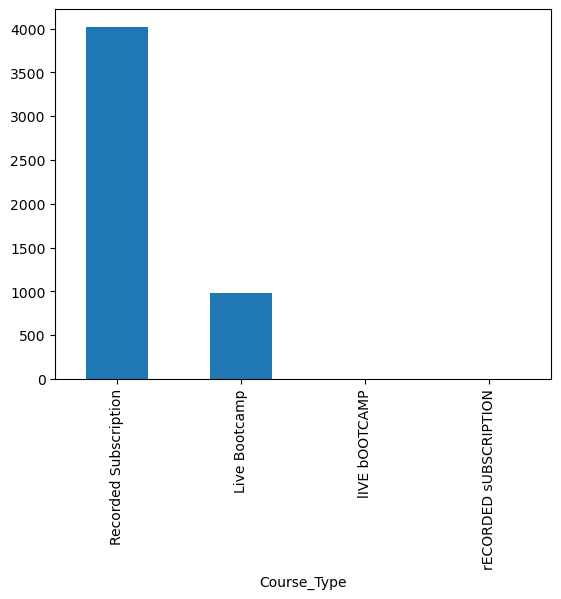

In [64]:
type_counts.plot(kind="bar")

### تنضيف البيانات \ Data Cleaning

In [129]:
# creating a copy from dataset
clean_df = df.copy()

In [130]:
#معرفة النواتج الفاضية 
clean_df.isnull().sum()

Invoice_ID          0
City                0
Course_Type         0
Price               0
Discount            0
Final_Total         0
Enrollment_Date     0
Rating             50
Course_Name         0
Level               0
dtype: int64

### في  50 صف فارغ في التقييم


مبدئيا البيانات مو نظيفة تحتاج تنظيف في نقص في عمود التقييم والتواريخ مو موحدة  واحتاج تفاصيل الكورس بدل ماهو اسم اكورس واللفل فعمود واحد اقسمها افضل واسهل عشا الترتيب

In [131]:
# فحص اذا في تكرارات 
clean_df.duplicated().sum()
#لايوجد تكرارات

np.int64(0)

### Data processing \ معالجة البيانات 

In [132]:
# Course_Details \ فصل عمود ال 
clean_df["Course_Details"] = clean_df["Course_Details"].str.split("|")
clean_df = clean_df.explode("Level")

KeyError: 'Course_Details'

In [133]:
clean_df.head(20)

,Invoice_ID,City,Course_Type,Price,Discount,Final_Total,Enrollment_Date,Rating,Course_Name,Level
0,INV-10001,Mecca,Recorded Subscription,532,266,266,3/17/2023,4.1,Laravel & PHP,Advanced
1,INV-10002,Jeddah,Recorded Subscription,289,0,289,"2023, March 15",4.5,Laravel & PHP,Beginner
2,INV-10003,Dammam,Recorded Subscription,474,94,380,"2023, March 15",4.4,UI/UX Design,Intermediate
3,INV-10004,Khobar,Recorded Subscription,265,0,265,"2023, March 15",4.7,UI/UX Design,Beginner
4,INV-10005,Mecca,Recorded Subscription,228,45,183,22-03-2023,4.6,React & Next.js,Beginner
5,INV-10006,Riyadh,Live Bootcamp,1542,0,1542,1/1/1900,4.5,Flutter Development,Beginner
6,INV-10007,Khobar,Recorded Subscription,269,134,135,10/2/2023,4.5,Flutter Development,Beginner
7,INV-10008,Tabuk,Recorded Subscription,211,42,169,"2023, March 15",4.7,Data Analysis,Beginner
8,INV-10009,Riyadh,Recorded Subscription,397,0,397,"2023, March 15",?,Flutter Development,Intermediate
9,INV-10010,Jeddah,Recorded Subscription,292,0,292,8/3/2023,4.6,Python Basics,Beginner


In [134]:
#تعويض النقص في الريتينق
clean_df['Rating'] = clean_df['Rating'].replace('?', pd.NA)
clean_df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
clean_df['Rating'] = clean_df['Rating'].fillna(clean_df['Rating'].mean())

In [137]:
# تعديل الى بس فاصلة واحدة \ Rating 
clean_df["Rating"] = clean_df["Rating"].astype(float).round(1)

In [138]:
#تحويل السعر الى float
clean_df["Price"] = clean_df["Price"].replace('[^0-9.]', '', regex=True)
clean_df["Price"] = clean_df["Price"].astype(float)

In [140]:
#معرفة صيغ التواريخ 
clean_df["Enrollment_Date"].unique()[:20]

array(['3/17/2023', '2023, March 15', '22-03-2023', '1/1/1900',
       '10/2/2023', '8/3/2023', '13-12-2023', '10/17/2023', '12/16/2023',
       '20-02-2023', '14-07-2023', '19-07-2023', '21-03-2023', '9/7/2023',
       '10/1/2023', '10/13/2023', '8/11/2023', '1/5/2023', '10/24/2023',
       '1/25/2024'], dtype=object)

In [141]:
#توحيد التاريخ 
# تحويل التاريخ (يدعم كل التنسيقات)
clean_df["Enrollment_Date"] = pd.to_datetime(clean_df["Enrollment_Date"], errors="coerce", format="mixed", dayfirst=True)
# أي قيمة فشلت → نحولها لقيمة افتراضية 
clean_df["Enrollment_Date"] = clean_df["Enrollment_Date"].fillna(pd.Timestamp("2000-01-01"))
# توحيد الشكل
clean_df["Enrollment_Date"] = clean_df["Enrollment_Date"].dt.strftime("%Y-%m-%d")

In [145]:
clean_df.head(20)

,Invoice_ID,City,Course_Type,Price,Discount,Final_Total,Enrollment_Date,Rating,Course_Name,Level
0,INV-10001,Mecca,Recorded Subscription,532.0,266,266,2023-03-17,4.1,Laravel & PHP,Advanced
1,INV-10002,Jeddah,Recorded Subscription,289.0,0,289,2023-03-15,4.5,Laravel & PHP,Beginner
2,INV-10003,Dammam,Recorded Subscription,474.0,94,380,2023-03-15,4.4,UI/UX Design,Intermediate
3,INV-10004,Khobar,Recorded Subscription,265.0,0,265,2023-03-15,4.7,UI/UX Design,Beginner
4,INV-10005,Mecca,Recorded Subscription,228.0,45,183,2023-03-22,4.6,React & Next.js,Beginner
5,INV-10006,Riyadh,Live Bootcamp,1542.0,0,1542,1900-01-01,4.5,Flutter Development,Beginner
6,INV-10007,Khobar,Recorded Subscription,269.0,134,135,2023-02-10,4.5,Flutter Development,Beginner
7,INV-10008,Tabuk,Recorded Subscription,211.0,42,169,2023-03-15,4.7,Data Analysis,Beginner
8,INV-10009,Riyadh,Recorded Subscription,397.0,0,397,2023-03-15,4.4,Flutter Development,Intermediate
9,INV-10010,Jeddah,Recorded Subscription,292.0,0,292,2023-03-08,4.6,Python Basics,Beginner


### Data Analysis \ تحليل البيانات

In [147]:
clean_df["Course_Name"].value_counts()

Course_Name
Python Basics          871
UI/UX Design           845
Laravel & PHP          839
React & Next.js        830
Flutter Development    827
Data Analysis          790
Name: count, dtype: int64

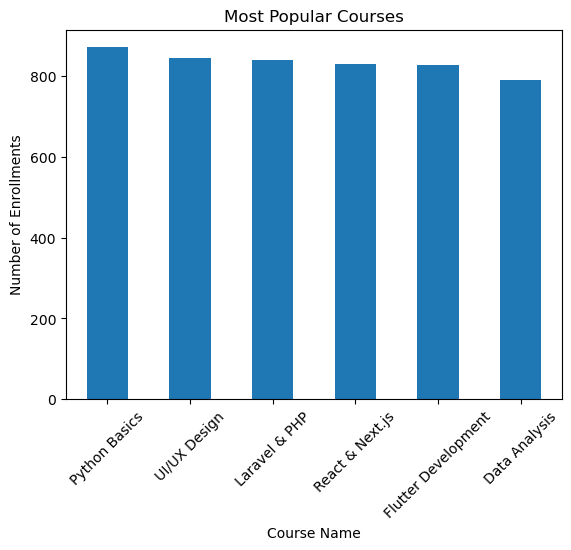

In [168]:
import matplotlib.pyplot as plt

clean_df["Course_Name"].value_counts().plot(kind="bar")
plt.title("Most Popular Courses")
plt.xlabel("Course Name")
plt.ylabel("Number of Enrollments")
plt.xticks(rotation=45)
plt.show()

In [149]:
# Python Basics \ اكثر كورس عليه اقبال هو

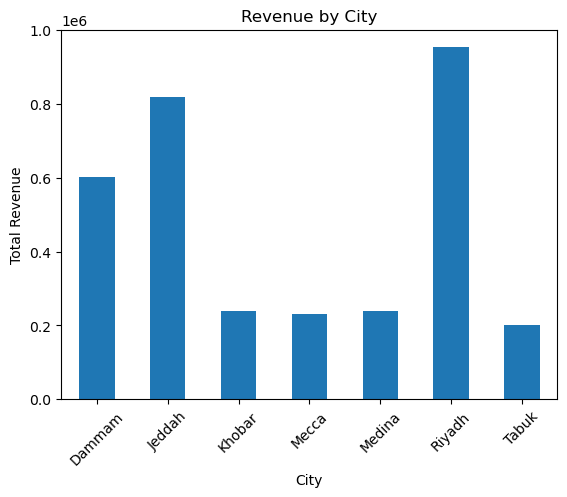

In [179]:
#الإيرادات حسب المدينة
clean_df.groupby("City")["Final_Total"].sum().plot(kind="bar")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [172]:
#متوسط التقييم لكل كورس
clean_df.groupby("Course_Name")["Rating"].mean().sort_values(ascending=False)

Course_Name
React & Next.js        4.390482
Laravel & PHP          4.385221
Flutter Development    4.381378
Python Basics          4.379334
Data Analysis          4.375696
UI/UX Design           4.375385
Name: Rating, dtype: float64

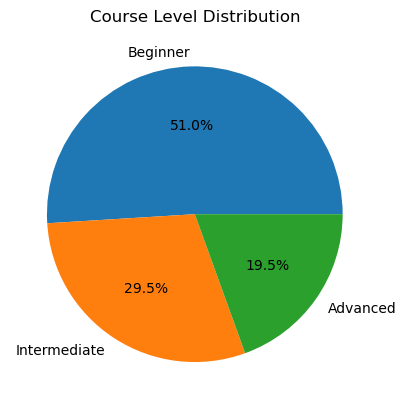

<Figure size 800x500 with 0 Axes>

In [ ]:
# نسب المستويات
clean_df["Level"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Course Level Distribution")
plt.ylabel("")
plt.show()


### الاستنتاجات:
### 1- الكورس الأكثر طلبًا هو (Python Basics)، وهذا يدل على أن المستخدمين مهتمين بمجال البرمجة ويمكن الاستثمار فيه أكثر عن طريق تطوير مهاراتهم في البرمجة .
### 2- مدينة (الرياض) تحقق أعلى إيرادات، مما يشير إلى أنها السوق الأقوى ويجب التركيز عليها في الحملات التسويقية
### 3- أغلب المستخدمين من مستوى Beginner، مما يعني أن المستهدفين هم المبتدئين بشكل كبير.